#  Notebook 03 — Comparaison de Modèles, Tuning & Évaluation Finale
### Amazon Fine Food Reviews · IASD Big Data Project 2025-2026

---

##  Objectif

Comparer 3 classifieurs, sélectionner le meilleur, sauvegarder le pipeline de production.

| Étape | Action | Sortie |
|-------|--------|--------|
| **1** | Chargement splits prétraités | DataFrames Parquet |
| **2** | Calcul des class weights | Poids équilibrés |
| **3** | Baseline Logistic Regression | Première référence |
| **4** | Comparaison 3 modèles (LR / NB / RF) | Tableau comparatif |
| **5** | Tuning hyperparamètres (Val Set) | Meilleurs paramètres |
| **6** | Évaluation finale Test Set | F1 & Accuracy réels |
| **7** | Analyse d'erreurs | Insights par classe |
| **8** | Sauvegarde modèle production | `models/final_best_model` |




In [ ]:

# ============================================================
# SECTION 1 — Setup & Chargement des Splits Parquet
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count
from pyspark.ml.classification import (
    LogisticRegression, NaiveBayes, RandomForestClassifier
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import PipelineModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, os

spark = SparkSession.builder \
    .appName("03_Model_Comparison") \
    .config("spark.driver.memory", "14g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

# Charger les splits prétraités produits par Notebook 02
print("Chargement des splits Parquet...")
train_df = spark.read.parquet("data/train_transformed").cache()
val_df   = spark.read.parquet("data/val_transformed").cache()
test_df  = spark.read.parquet("data/test_transformed").cache()

n_train = train_df.count()
n_val   = val_df.count()
n_test  = test_df.count()
total   = n_train + n_val + n_test

print(f"Train      : {n_train:>9,}  ({n_train/total*100:.1f}%)")
print(f"Validation : {n_val:>9,}  ({n_val/total*100:.1f}%)")
print(f"Test       : {n_test:>9,}  ({n_test/total*100:.1f}%)  ← VERROUILLÉ")

LABEL_MAP    = {0.0: "Négatif", 1.0: "Neutre", 2.0: "Positif"}
LABEL_COLORS = {"Négatif": "#e74c3c", "Neutre": "#f39c12", "Positif": "#2ecc71"}
LABEL_ORDER  = ["Négatif", "Neutre", "Positif"]

# ============================================================
# SECTION 2 — Calcul des Class Weights
# ============================================================
# EDA Constat #1 : 78% Positif → sans compensation, le modèle prédit
# "Positif" pour tout et atteint 78% d'accuracy tout en étant inutile.
#
# Formule : weight_i = N / (K × count_i)
# → chaque classe contribue équitablement à la loss

class_counts_rows = train_df.groupBy("label_idx").count().collect()
class_counts = {float(r["label_idx"]): float(r["count"]) for r in class_counts_rows}
N = float(train_df.count())
K = 3.0

print("\n=== Calcul des Class Weights ===")
print(f"{'Classe':<12} {'label_idx':>10} {'Count':>10} {'%':>7} {'Weight':>10}")
print("-"*52)
for idx in [0.0, 1.0, 2.0]:
    cnt  = class_counts.get(idx, 1)
    pct  = cnt / N * 100
    w    = N / (K * cnt)
    name = LABEL_MAP[idx]
    print(f"{name:<12} {idx:>10.1f} {cnt:>10,.0f} {pct:>6.1f}% {w:>10.4f}")

print("\nOrdre attendu : Neutre > Négatif > Positif")
print("(la classe la plus rare reçoit le poids le plus élevé)")

train_weighted = train_df.withColumn("classWeight",
    when(col("label_idx") == 0.0, N / (K * class_counts[0.0]))   # Négatif
    .when(col("label_idx") == 1.0, N / (K * class_counts[1.0]))  # Neutre ← plus élevé
    .otherwise(                    N / (K * class_counts[2.0]))   # Positif ← plus bas
)
train_weighted.cache()
print(" Poids calculés et appliqués au DataFrame d'entraînement.")


Chargement des splits Parquet...
Train      :   315,004  (80.0%)
Validation :    39,230  (10.0%)
Test       :    39,344  (10.0%)  ← VERROUILLÉ

=== Calcul des Class Weights ===
Classe        label_idx      Count       %     Weight
----------------------------------------------------
Négatif             0.0     45,646   14.5%     2.3003
Neutre              1.0     23,724    7.5%     4.4260
Positif             2.0    245,634   78.0%     0.4275

Ordre attendu : Neutre > Négatif > Positif
(la classe la plus rare reçoit le poids le plus élevé)
 Poids calculés et appliqués au DataFrame d'entraînement.



[1/3] Logistic Regression...
Entraîné en 163.5s

───────────────────────────────────────────────────────
  Logistic Regression (maxIter=30, regParam=0.05)
───────────────────────────────────────────────────────
  Val Accuracy  : 0.8208
  Val F1 Macro  : 0.8414
  Val F1 Weighted: 0.8414

  Classe        Precision     Recall         F1
  ────────────────────────────────────────────
  Négatif          0.6834     0.7543     0.7171
  Neutre           0.2863     0.5572     0.3782
  Positif          0.9672     0.8590     0.9099

[2/3] Naive Bayes...
Entraîné en 6.8s

───────────────────────────────────────────────────────
  Naive Bayes (smoothing=1.0) [sans classWeight]
───────────────────────────────────────────────────────
  Val Accuracy  : 0.7904
  Val F1 Macro  : 0.8161
  Val F1 Weighted: 0.8161

  Classe        Precision     Recall         F1
  ────────────────────────────────────────────
  Négatif          0.6292     0.7195     0.6713
  Neutre           0.2603     0.5616     0.3557
  P

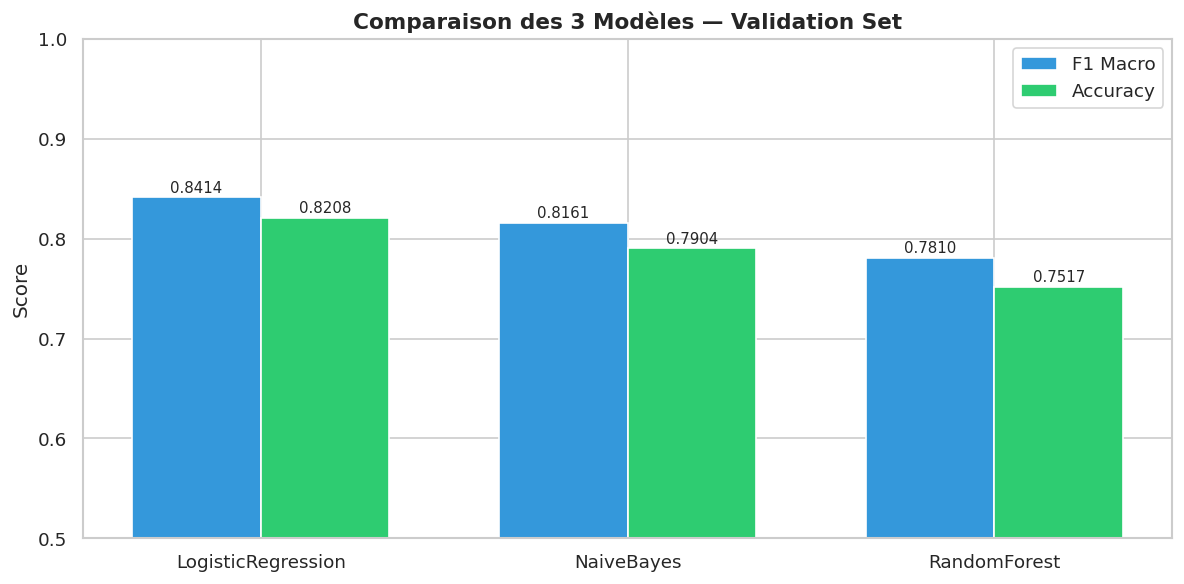

In [ ]:

# ============================================================
# SECTION 3 — Fonction d'Évaluation & Comparaison 3 Modèles
# ============================================================

def evaluate_on_val(model, label=""):
    """
    Évalue un modèle sur le Validation Set uniquement.
    NE TOUCHE PAS au test set.
    Retourne un dict de métriques + les prédictions.
    """
    preds = model.transform(val_df)

    acc  = MulticlassClassificationEvaluator(
        labelCol="label_idx", metricName="accuracy").evaluate(preds)
    f1   = MulticlassClassificationEvaluator(
        labelCol="label_idx", metricName="f1").evaluate(preds)
    f1w  = MulticlassClassificationEvaluator(
        labelCol="label_idx", metricName="weightedFMeasure").evaluate(preds)

    per_class = {}
    for idx in [0.0, 1.0, 2.0]:
        tp = preds.filter((col("label_idx")==idx) & (col("prediction")==idx)).count()
        fp = preds.filter((col("label_idx")!=idx) & (col("prediction")==idx)).count()
        fn = preds.filter((col("label_idx")==idx) & (col("prediction")!=idx)).count()
        pr = tp/(tp+fp) if (tp+fp)>0 else 0
        rc = tp/(tp+fn) if (tp+fn)>0 else 0
        f1c= 2*pr*rc/(pr+rc) if (pr+rc)>0 else 0
        per_class[idx] = {"precision": pr, "recall": rc, "f1": f1c}

    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Val Accuracy  : {acc:.4f}")
    print(f"  Val F1 Macro  : {f1:.4f}")
    print(f"  Val F1 Weighted: {f1w:.4f}")
    print(f"\n  {'Classe':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'─'*44}")
    for idx in [0.0, 1.0, 2.0]:
        m = per_class[idx]
        print(f"  {LABEL_MAP[idx]:<12} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

    return {"acc": acc, "f1": f1, "f1w": f1w, "per_class": per_class, "preds": preds}


# ============================================================
# Entraînement & comparaison des 3 modèles
# ============================================================

comparison_results = []

# ─── Modèle 1 : Logistic Regression ─────────────────────────
# Supporte classWeight. Excellent pour la classification de texte TF-IDF.
print("\n[1/3] Logistic Regression...")
lr = LogisticRegression(
    featuresCol="features", labelCol="label_idx", weightCol="classWeight",
    maxIter=30, regParam=0.05, elasticNetParam=0.0, family="multinomial"
)
t0 = time.time()
model_lr = lr.fit(train_weighted)
elapsed_lr = time.time() - t0
print(f"Entraîné en {elapsed_lr:.1f}s")
res_lr = evaluate_on_val(model_lr, "Logistic Regression (maxIter=30, regParam=0.05)")
comparison_results.append({"Modèle": "LogisticRegression", "Val F1": res_lr["f1"],
                            "Val Acc": res_lr["acc"], "Temps(s)": elapsed_lr,
                            "model": model_lr, "results": res_lr})

# ─── Modèle 2 : Naive Bayes ───────────────────────────────────
# IMPORTANT : NaiveBayes ne supporte PAS weightCol dans PySpark MLlib.
# Utiliser weightCol avec NB provoque un crash ou un résultat incorrect.
# On entraîne NB sans weightCol → ses résultats seront moins bons sur Neutre.
print("\n[2/3] Naive Bayes...")
nb = NaiveBayes(
    featuresCol="features", labelCol="label_idx",
    smoothing=1.0, modelType="multinomial"
    # PAS de weightCol — non supporté par PySpark NaiveBayes
)
t0 = time.time()
model_nb = nb.fit(train_df)   # train_df sans poids (intentionnel)
elapsed_nb = time.time() - t0
print(f"Entraîné en {elapsed_nb:.1f}s")
res_nb = evaluate_on_val(model_nb, "Naive Bayes (smoothing=1.0) [sans classWeight]")
comparison_results.append({"Modèle": "NaiveBayes", "Val F1": res_nb["f1"],
                            "Val Acc": res_nb["acc"], "Temps(s)": elapsed_nb,
                            "model": model_nb, "results": res_nb})

# ─── Modèle 3 : Random Forest ─────────────────────────────────
# Supporte classWeight. Plus lent mais capture des non-linéarités.
# On réduit numTrees=50 pour ne pas dépasser 20 min d'entraînement.
print("\n[3/3] Random Forest...")
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label_idx",
    weightCol="classWeight",
    numTrees=50, maxDepth=10,
    seed=42
)
t0 = time.time()
model_rf = rf.fit(train_weighted)
elapsed_rf = time.time() - t0
print(f"Entraîné en {elapsed_rf:.1f}s")
res_rf = evaluate_on_val(model_rf, "Random Forest (50 trees, maxDepth=10)")
comparison_results.append({"Modèle": "RandomForest", "Val F1": res_rf["f1"],
                            "Val Acc": res_rf["acc"], "Temps(s)": elapsed_rf,
                            "model": model_rf, "results": res_rf})

# ─── Tableau comparatif ────────────────────────────────────────
print("\n" + "="*60)
print("  TABLEAU COMPARATIF — Validation Set")
print("="*60)
comp_df = pd.DataFrame([{
    "Modèle": r["Modèle"],
    "Val F1 Macro": f"{r['Val F1']:.4f}",
    "Val Accuracy": f"{r['Val Acc']:.4f}",
    "Temps (s)": f"{r['Temps(s)']:.1f}",
} for r in comparison_results]).sort_values("Val F1 Macro", ascending=False)
print(comp_df.to_string(index=False))

# ─── Plot comparatif ───────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

models_names = [r["Modèle"] for r in comparison_results]
f1_values    = [r["Val F1"] for r in comparison_results]
acc_values   = [r["Val Acc"] for r in comparison_results]

x = np.arange(len(models_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1_values,  width, label="F1 Macro",  color="#3498db", edgecolor="white")
bars2 = ax.bar(x + width/2, acc_values, width, label="Accuracy",  color="#2ecc71", edgecolor="white")
ax.set_title("Comparaison des 3 Modèles — Validation Set", fontweight="bold", fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(models_names)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("Score")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.4f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


Tuning Logistic Regression sur Val Set...

Params                                Val F1  Val Acc   Temps
──────────────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  LR maxIter=30 reg=0.1
───────────────────────────────────────────────────────
  Val Accuracy  : 0.8229
  Val F1 Macro  : 0.8435
  Val F1 Weighted: 0.8435

  Classe        Precision     Recall         F1
  ────────────────────────────────────────────
  Négatif          0.6875     0.7646     0.7240
  Neutre           0.2932     0.5740     0.3881
  Positif          0.9691     0.8581     0.9103
  maxIter=30, reg=0.1                 0.8435   0.8229   83.5s

───────────────────────────────────────────────────────
  LR maxIter=30 reg=0.05
───────────────────────────────────────────────────────
  Val Accuracy  : 0.8208
  Val F1 Macro  : 0.8414
  Val F1 Weighted: 0.8414

  Classe        Precision     Recall         F1
  ────────────────────────────────────────────
  Négat

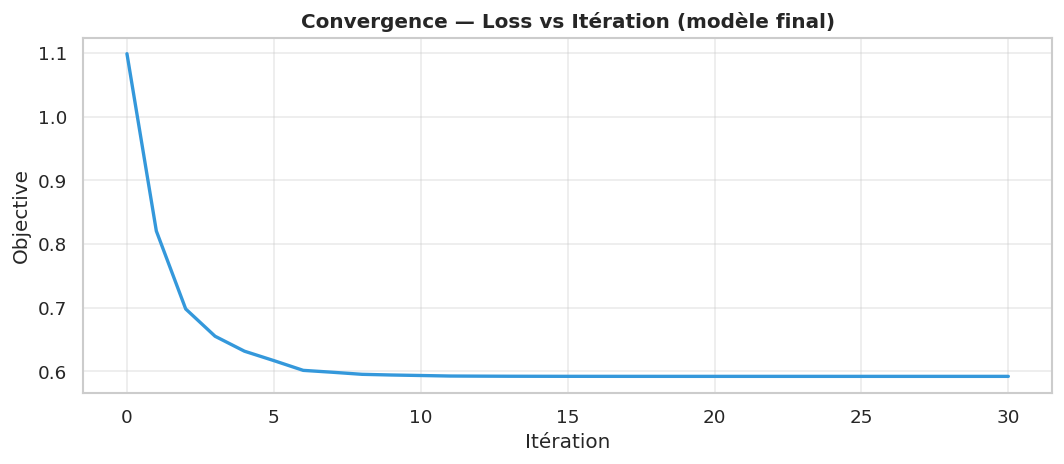


   ÉVALUATION FINALE — TEST SET
  (Première et unique utilisation)

  Test Accuracy    : 0.8197
  Test F1 Macro    : 0.8405
  Test F1 Weighted : 0.8405

  Classe        Precision     Recall         F1
  ────────────────────────────────────────────
  Négatif          0.6843     0.7617     0.7209
  Neutre           0.2918     0.5707     0.3862
  Positif          0.9679     0.8553     0.9081

  Matrice de confusion (Test) :
                 Préd Nég   Préd Neu   Préd Pos
  Vrai Négatif      4,366      1,038        328
  Vrai Neutre         766      1,736        540
  Vrai Positif      1,248      3,175     26,147


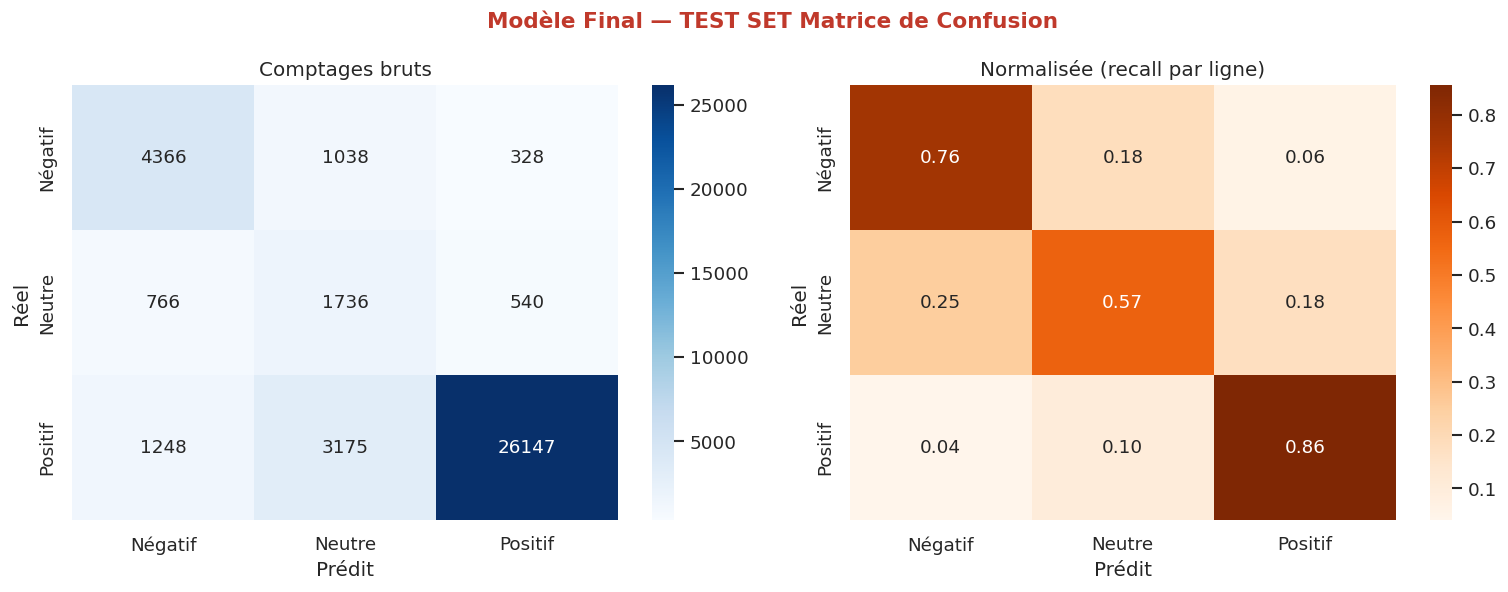


  Val F1 : 0.8435  |  Test F1 : 0.8405  |  Delta : -0.0030
   Pas de surapprentissage significatif (gap < 2%)

=== Patterns d'erreurs les plus fréquents ===
+---------+----------+-----+
|label_idx|prediction|count|
+---------+----------+-----+
|      2.0|       1.0| 3175|
|      2.0|       0.0| 1248|
|      0.0|       1.0| 1038|
|      1.0|       0.0|  766|
|      1.0|       2.0|  540|
|      0.0|       2.0|  328|
+---------+----------+-----+



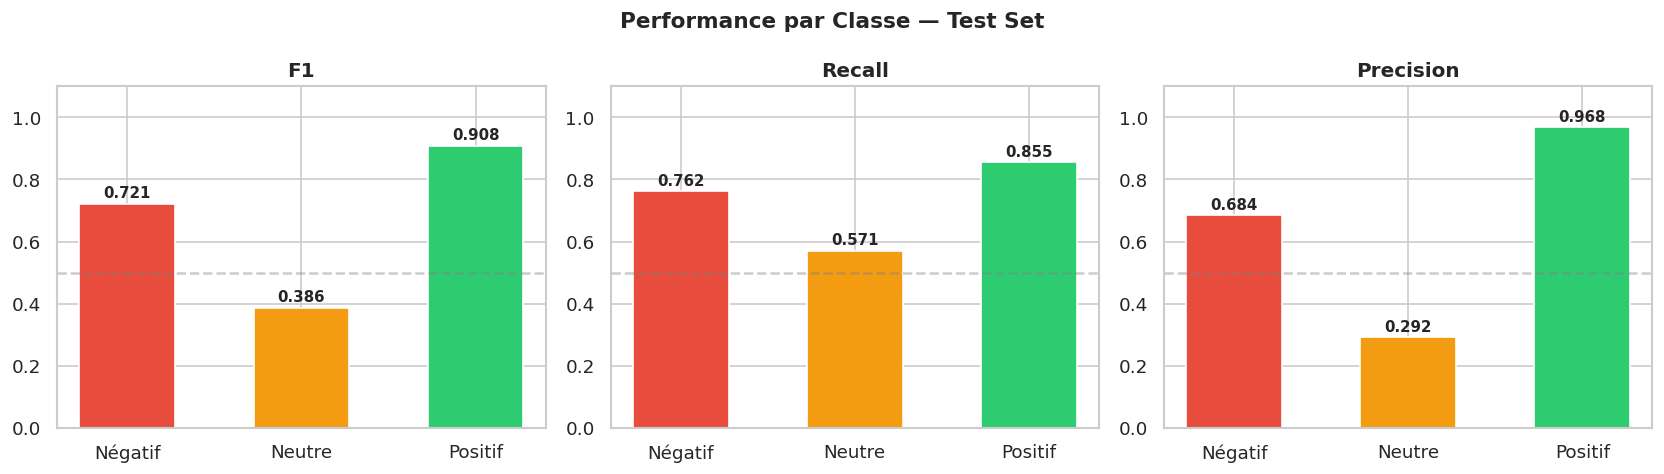


 Modèle sauvegardé : models/final_best_model

  MODEL CARD — Résumé Production
  Algorithme     : Logistic Regression (PySpark MLlib)
  Features       : TF-IDF Unigrams + Bigrams (~20K features)
  maxIter        : 30
  regParam       : 0.1
  Class weights  : N / (K × count)
  Test F1 Macro  : 0.8405
  Test Accuracy  : 0.8197
  Mapping labels : 0.0=Négatif  1.0=Neutre  2.0=Positif

Fichiers produits :
  models/preprocessing_pipeline/  ← Notebook 02
  models/final_best_model/        ← ce notebook

Pour le Data Engineer (Spark Streaming) :
  → Charger preprocessing_pipeline + final_best_model
  → Voir Section 9 du Notebook 03 pour le code complet


In [ ]:

# ============================================================
# SECTION 4 — Tuning Hyperparamètres (Val Set uniquement)
# ============================================================
# On affine le meilleur modèle sur le Val Set.
# Le Test Set n'est toujours pas touché.

print("Tuning Logistic Regression sur Val Set...")
param_grid = [
    {"maxIter": 30,  "regParam": 0.10},
    {"maxIter": 30,  "regParam": 0.05},
    {"maxIter": 50,  "regParam": 0.05},
    {"maxIter": 50,  "regParam": 0.01},
    {"maxIter": 100, "regParam": 0.05},
    {"maxIter": 100, "regParam": 0.01},
]

tuning_results = []
print(f"\n{'Params':<35} {'Val F1':>8} {'Val Acc':>8} {'Temps':>7}")
print("─"*62)

for params in param_grid:
    lr_tune = LogisticRegression(
        featuresCol="features", labelCol="label_idx", weightCol="classWeight",
        maxIter=params["maxIter"], regParam=params["regParam"],
        elasticNetParam=0.0, family="multinomial"
    )
    t0 = time.time()
    m  = lr_tune.fit(train_weighted)
    elapsed = time.time() - t0
    res = evaluate_on_val(m, f"LR maxIter={params['maxIter']} reg={params['regParam']}")
    label = f"maxIter={params['maxIter']}, reg={params['regParam']}"
    print(f"  {label:<33} {res['f1']:>8.4f} {res['acc']:>8.4f} {elapsed:>6.1f}s")
    tuning_results.append({**params, "f1": res["f1"], "acc": res["acc"],
                           "model": m, "results": res})

best_run = max(tuning_results, key=lambda x: x["f1"])
print(f"\n Meilleurs paramètres :")
print(f"   maxIter  = {best_run['maxIter']}")
print(f"   regParam = {best_run['regParam']}")
print(f"   Val F1   = {best_run['f1']:.4f}")

# ============================================================
# SECTION 5 — Réentraînement Final (Train + Val combinés)
# ============================================================
# Bonne pratique : une fois les hyperparamètres fixés,
# on réentraîne sur Train + Val pour maximiser les données.

print("\nRéentraînement sur Train + Val combinés...")
train_full = train_df.union(val_df)

full_counts = {float(r["label_idx"]): float(r["count"])
               for r in train_full.groupBy("label_idx").count().collect()}
N_full = float(train_full.count())
K = 3.0

train_full_weighted = train_full.withColumn("classWeight",
    when(col("label_idx") == 0.0, N_full / (K * full_counts[0.0]))
    .when(col("label_idx") == 1.0, N_full / (K * full_counts[1.0]))
    .otherwise(                    N_full / (K * full_counts[2.0]))
)

lr_final = LogisticRegression(
    featuresCol="features", labelCol="label_idx", weightCol="classWeight",
    maxIter=best_run["maxIter"], regParam=best_run["regParam"],
    elasticNetParam=0.0, family="multinomial"
)
t0 = time.time()
final_model = lr_final.fit(train_full_weighted)
print(f" Modèle final entraîné en {time.time()-t0:.1f}s sur {N_full:,.0f} exemples")

# Courbe de convergence
history = final_model.summary.objectiveHistory
if history:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(len(history)), history, color="#3498db", linewidth=2)
    ax.set_title("Convergence — Loss vs Itération (modèle final)", fontweight="bold")
    ax.set_xlabel("Itération"); ax.set_ylabel("Objective")
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("training_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()

# ============================================================
# SECTION 6 —  ÉVALUATION FINALE SUR LE TEST SET
# ============================================================
# Ce bloc est exécuté UNE SEULE FOIS.
# Le test set n'a jamais été vu pendant l'entraînement ou le tuning.

print("\n" + "="*60)
print("   ÉVALUATION FINALE — TEST SET")
print("  (Première et unique utilisation)")
print("="*60)

test_preds = final_model.transform(test_df)

acc_test = MulticlassClassificationEvaluator(
    labelCol="label_idx", metricName="accuracy").evaluate(test_preds)
f1_test  = MulticlassClassificationEvaluator(
    labelCol="label_idx", metricName="f1").evaluate(test_preds)
f1w_test = MulticlassClassificationEvaluator(
    labelCol="label_idx", metricName="weightedFMeasure").evaluate(test_preds)

print(f"\n  Test Accuracy    : {acc_test:.4f}")
print(f"  Test F1 Macro    : {f1_test:.4f}")
print(f"  Test F1 Weighted : {f1w_test:.4f}")

# Métriques par classe
print(f"\n  {'Classe':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'─'*44}")
per_class_test = {}
for idx in [0.0, 1.0, 2.0]:
    tp = test_preds.filter((col("label_idx")==idx) & (col("prediction")==idx)).count()
    fp = test_preds.filter((col("label_idx")!=idx) & (col("prediction")==idx)).count()
    fn = test_preds.filter((col("label_idx")==idx) & (col("prediction")!=idx)).count()
    pr = tp/(tp+fp) if (tp+fp)>0 else 0
    rc = tp/(tp+fn) if (tp+fn)>0 else 0
    f1c= 2*pr*rc/(pr+rc) if (pr+rc)>0 else 0
    per_class_test[idx] = {"prec": pr, "recall": rc, "f1": f1c}
    print(f"  {LABEL_MAP[idx]:<12} {pr:>10.4f} {rc:>10.4f} {f1c:>10.4f}")

# Matrice de confusion
print("\n  Matrice de confusion (Test) :")
cm_data = test_preds.groupBy("label_idx","prediction").count().orderBy("label_idx","prediction").collect()
cm_dict = {(float(r["label_idx"]), float(r["prediction"])): r["count"] for r in cm_data}

print(f"  {'':12} {'Préd Nég':>10} {'Préd Neu':>10} {'Préd Pos':>10}")
for ti in [0.0, 1.0, 2.0]:
    vals = [cm_dict.get((ti, pi), 0) for pi in [0.0,1.0,2.0]]
    print(f"  Vrai {LABEL_MAP[ti]:<7} {vals[0]:>10,} {vals[1]:>10,} {vals[2]:>10,}")

# Heatmap confusion matrix
import numpy as np
import seaborn as sns

cm_arr = np.array([
    [cm_dict.get((ti, pi), 0) for pi in [0.0,1.0,2.0]]
    for ti in [0.0,1.0,2.0]
], dtype=float)
cm_norm = cm_arr / cm_arr.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Modèle Final — TEST SET Matrice de Confusion",
             fontsize=13, fontweight="bold", color="#c0392b")

lbl = ["Négatif", "Neutre", "Positif"]
sns.heatmap(cm_arr, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=lbl, yticklabels=lbl, ax=axes[0])
axes[0].set_title("Comptages bruts")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=lbl, yticklabels=lbl, ax=axes[1])
axes[1].set_title("Normalisée (recall par ligne)")
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

# Check surapprentissage
best_val_f1 = best_run["f1"]
print(f"\n  Val F1 : {best_val_f1:.4f}  |  Test F1 : {f1_test:.4f}  "
      f"|  Delta : {f1_test-best_val_f1:+.4f}")
gap = abs(f1_test - best_val_f1)
if gap < 0.02:
    print("   Pas de surapprentissage significatif (gap < 2%)")
else:
    print(f"    Gap notable = {gap:.4f} — envisager une régularisation plus forte")

# ============================================================
# SECTION 7 — Analyse d'Erreurs
# ============================================================

print("\n=== Patterns d'erreurs les plus fréquents ===")
test_preds.filter(col("label_idx") != col("prediction")) \
    .groupBy("label_idx", "prediction").count() \
    .orderBy(col("count").desc()).show()

# Bar chart par classe
f1_vals  = [per_class_test[k]["f1"]     for k in [0.0, 1.0, 2.0]]
rec_vals = [per_class_test[k]["recall"] for k in [0.0, 1.0, 2.0]]
pre_vals = [per_class_test[k]["prec"]   for k in [0.0, 1.0, 2.0]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Performance par Classe — Test Set", fontsize=13, fontweight="bold")
for ax, (title, vals) in zip(axes, [("F1", f1_vals), ("Recall", rec_vals), ("Precision", pre_vals)]):
    colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
    bars = ax.bar(LABEL_ORDER, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("per_class_metrics_test.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# SECTION 8 — Sauvegarde du Modèle de Production
# ============================================================
import os
os.makedirs("models", exist_ok=True)

final_model.write().overwrite().save("models/final_best_model")
print("\n Modèle sauvegardé : models/final_best_model")

print("\n" + "="*60)
print("  MODEL CARD — Résumé Production")
print("="*60)
print(f"  Algorithme     : Logistic Regression (PySpark MLlib)")
print(f"  Features       : TF-IDF Unigrams + Bigrams (~20K features)")
print(f"  maxIter        : {best_run['maxIter']}")
print(f"  regParam       : {best_run['regParam']}")
print(f"  Class weights  : N / (K × count)")
print(f"  Test F1 Macro  : {f1_test:.4f}")
print(f"  Test Accuracy  : {acc_test:.4f}")
print(f"  Mapping labels : 0.0=Négatif  1.0=Neutre  2.0=Positif")
print("="*60)
print("\nFichiers produits :")
print("  models/preprocessing_pipeline/  ← Notebook 02")
print("  models/final_best_model/        ← ce notebook")
print("\nPour le Data Engineer (Spark Streaming) :")
print("  → Charger preprocessing_pipeline + final_best_model")
print("  → Voir Section 9 du Notebook 03 pour le code complet")


---
##  Résumé Final & Livrables

### Ce que ce notebook a produit

| Fichier | Description | Consommateur |
|---------|-------------|-------------|
| `models/final_best_model/` | Logistic Regression fitté | Spark Streaming, Airflow |
| `model_comparison.png` | Comparaison 3 modèles | Rapport / Présentation |
| `training_convergence.png` | Courbe de convergence | Rapport |
| `confusion_matrix_test.png` | Matrice de confusion finale | Rapport / Présentation |
| `per_class_metrics_test.png` | F1/Recall/Precision par classe | Rapport |


---

### Intégration dans l'architecture complète

```
Notebook 03 (ce notebook)
        │ produit
        ▼
models/final_best_model/
        │ chargé par
        ├── Spark Streaming → prédictions temps réel → MongoDB
        └── Airflow DAG     → réentraînement nuitamment → MLflow
                                      │
                                      ▼
                              Si F1 amélioré > 1% → remplace le modèle
                              Spark hot-reload dans les 60 secondes
```
